## Import mathematica CS data
The data is one matrix organized as 
$$
\begin{bmatrix}
\phi_1 & r_1 & Re(u(r_1)) & Im(u(r_1)) \\
\phi_1 & r_2 & Re(u(r_1)) & Im(u(r_1))\\
 & &\cdots & \\
\phi_2 & r_1 & Re(u(r_2)) & Im(u(r_2))\\
\phi_2 & r_2 & Re(u(r_2)) & Im(u(r_2))\\
& & \cdots&
\end{bmatrix}
$$

In [1]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem, TakagiRegularization
from src.dvr import DVR

import numpy as np
from numpy import pi, exp
import random
import matplotlib.pyplot as plt
import pandas as pd

import logging
logging.basicConfig(level=logging.WARNING, format="[%(levelname)s] %(name)s: %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

In [2]:
data = pd.read_csv("data/mathematica_CS_training_wavefunctions.csv", header=None)
data.columns = ['phi', 'r', 'u_re', 'u_im']

# collect all unique phi values in an array
phi_values = data['phi'].unique()

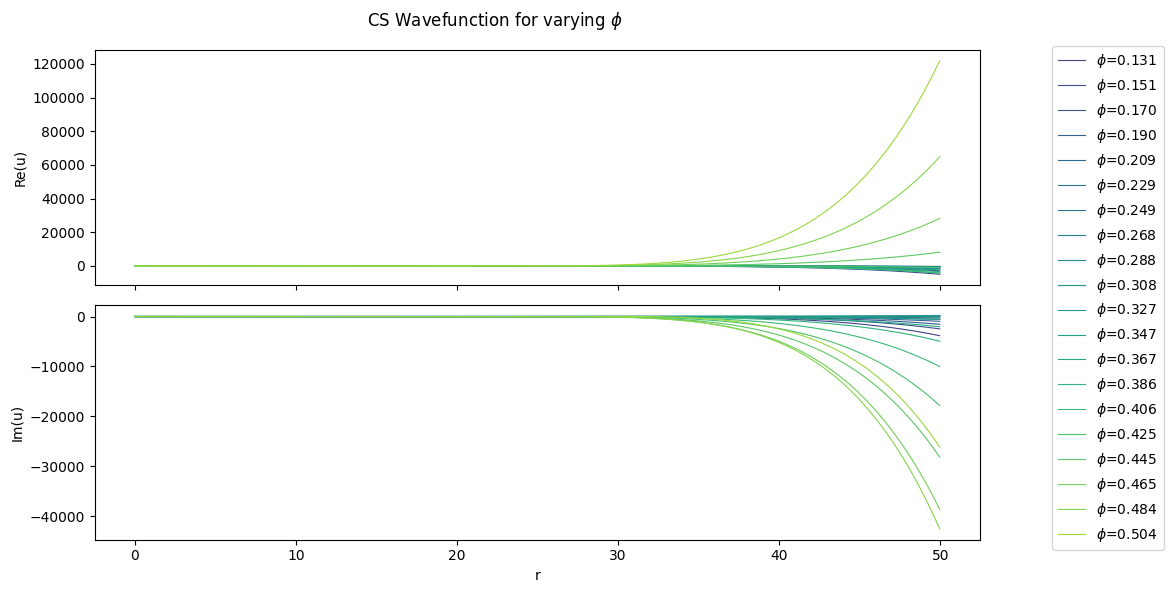

In [3]:
# plot all data
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(phi_values)))

for i, phi in enumerate(phi_values):
    subset = data[data['phi'] == phi]
    rs = subset['r'].values
    u_re = subset['u_re'].values
    u_im = subset['u_im'].values

    ax1.plot(rs, u_re, color=colors[i], label=rf'$\phi$={phi:.3f}', linewidth=0.8)
    ax2.plot(rs, u_im, color=colors[i], linewidth=0.8)

ax1.set_ylabel('Re(u)')
ax2.set_ylabel('Im(u)')
ax2.set_xlabel('r')
fig.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
fig.suptitle(r"CS Wavefunction for varying $\phi$")
plt.tight_layout()
plt.show()

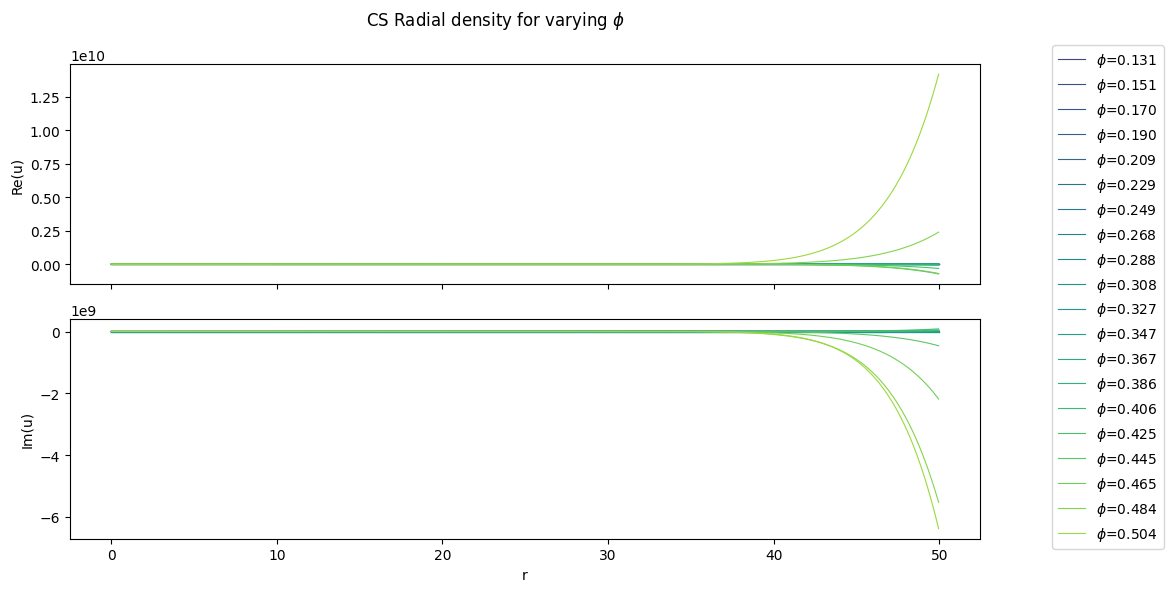

In [4]:
# plot radial density
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(phi_values)))

for i, phi in enumerate(phi_values):
    subset = data[data['phi'] == phi]
    rs = subset['r'].values
    u_re = subset['u_re'].values
    u_im = subset['u_im'].values
    u = u_re + 1j*u_im

    rho = u**2

    ax1.plot(rs, np.real(rho), color=colors[i], label=rf'$\phi$={phi:.3f}', linewidth=0.8)
    ax2.plot(rs, np.imag(rho), color=colors[i], linewidth=0.8)

ax1.set_ylabel('Re(u)')
ax2.set_ylabel('Im(u)')
ax2.set_xlabel('r')
fig.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
fig.suptitle(r"CS Radial density for varying $\phi$")
plt.tight_layout()
plt.show()

## Train EC on these wavefunctions and back-rotate to $\phi=0$.

First, convert wavefunction to DVR states for training data.

In [5]:
# set up DVR
n = 256
phi = pi / 24
real_res = 1.606 - 1j*0.047
L = 35

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)

In [9]:
# convert mathematica data to DVR states
states = []

for i, phi in enumerate(phi_values):
    subset = data[data['phi'] == phi]
    rs = subset['r'].values
    u_re = subset['u_re'].values
    u_im = subset['u_im'].values

    wavefunc = u_re + 1j*u_im
    state = test_system.position_space_to_DVR(rs, wavefunc)

    states.append(state)

states = np.array(states).T

In [7]:
# train EC on the mathematica states
test_ecsystem = ECSystem(test_system, real_res)
test_ecsystem.train_from_outside_data(phi_values, states)
test_ecsystem.construct_basis()

In [12]:
# predict energies and rr at phi=0
phi_predict = 0.0
energies, rrs = test_ecsystem.predict_energies_rrs(rotation_angles_predict=[phi_predict], rotate_rr=False)
print(f"Mathematica trained EC energy: {np.real(energies[0]):.4f} + i{np.imag(energies[0]):.4f}.")
print(f"Mathematica trained EC rr: {np.real(rrs[0]):.4f} + i{np.imag(rrs[0]):.4f}.")

Mathematica trained EC energy: 1.5882 + i-0.0416.
Mathematica trained EC rr: 0.5146 + i0.3624.


In [13]:
# plot wavefunction
x_plot = np.linspace(0.0, L, 500)
predicted_eigenstate_DVR = test_ecsystem.predict_DVR_state_at(phi_predict)[1]
mathematica_trained_prediction = test_ecsystem.system.DVR_to_position_space(predicted_eigenstate_DVR, x_plot)

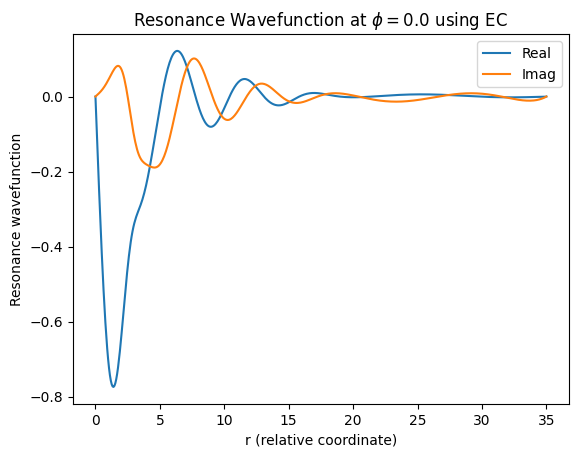

In [14]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(mathematica_trained_prediction), label='Real')
ax.plot(x_plot, np.imag(mathematica_trained_prediction), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=0.0$ using EC")
ax.legend()
plt.show()